# Figures

## Chop/Nod schematic

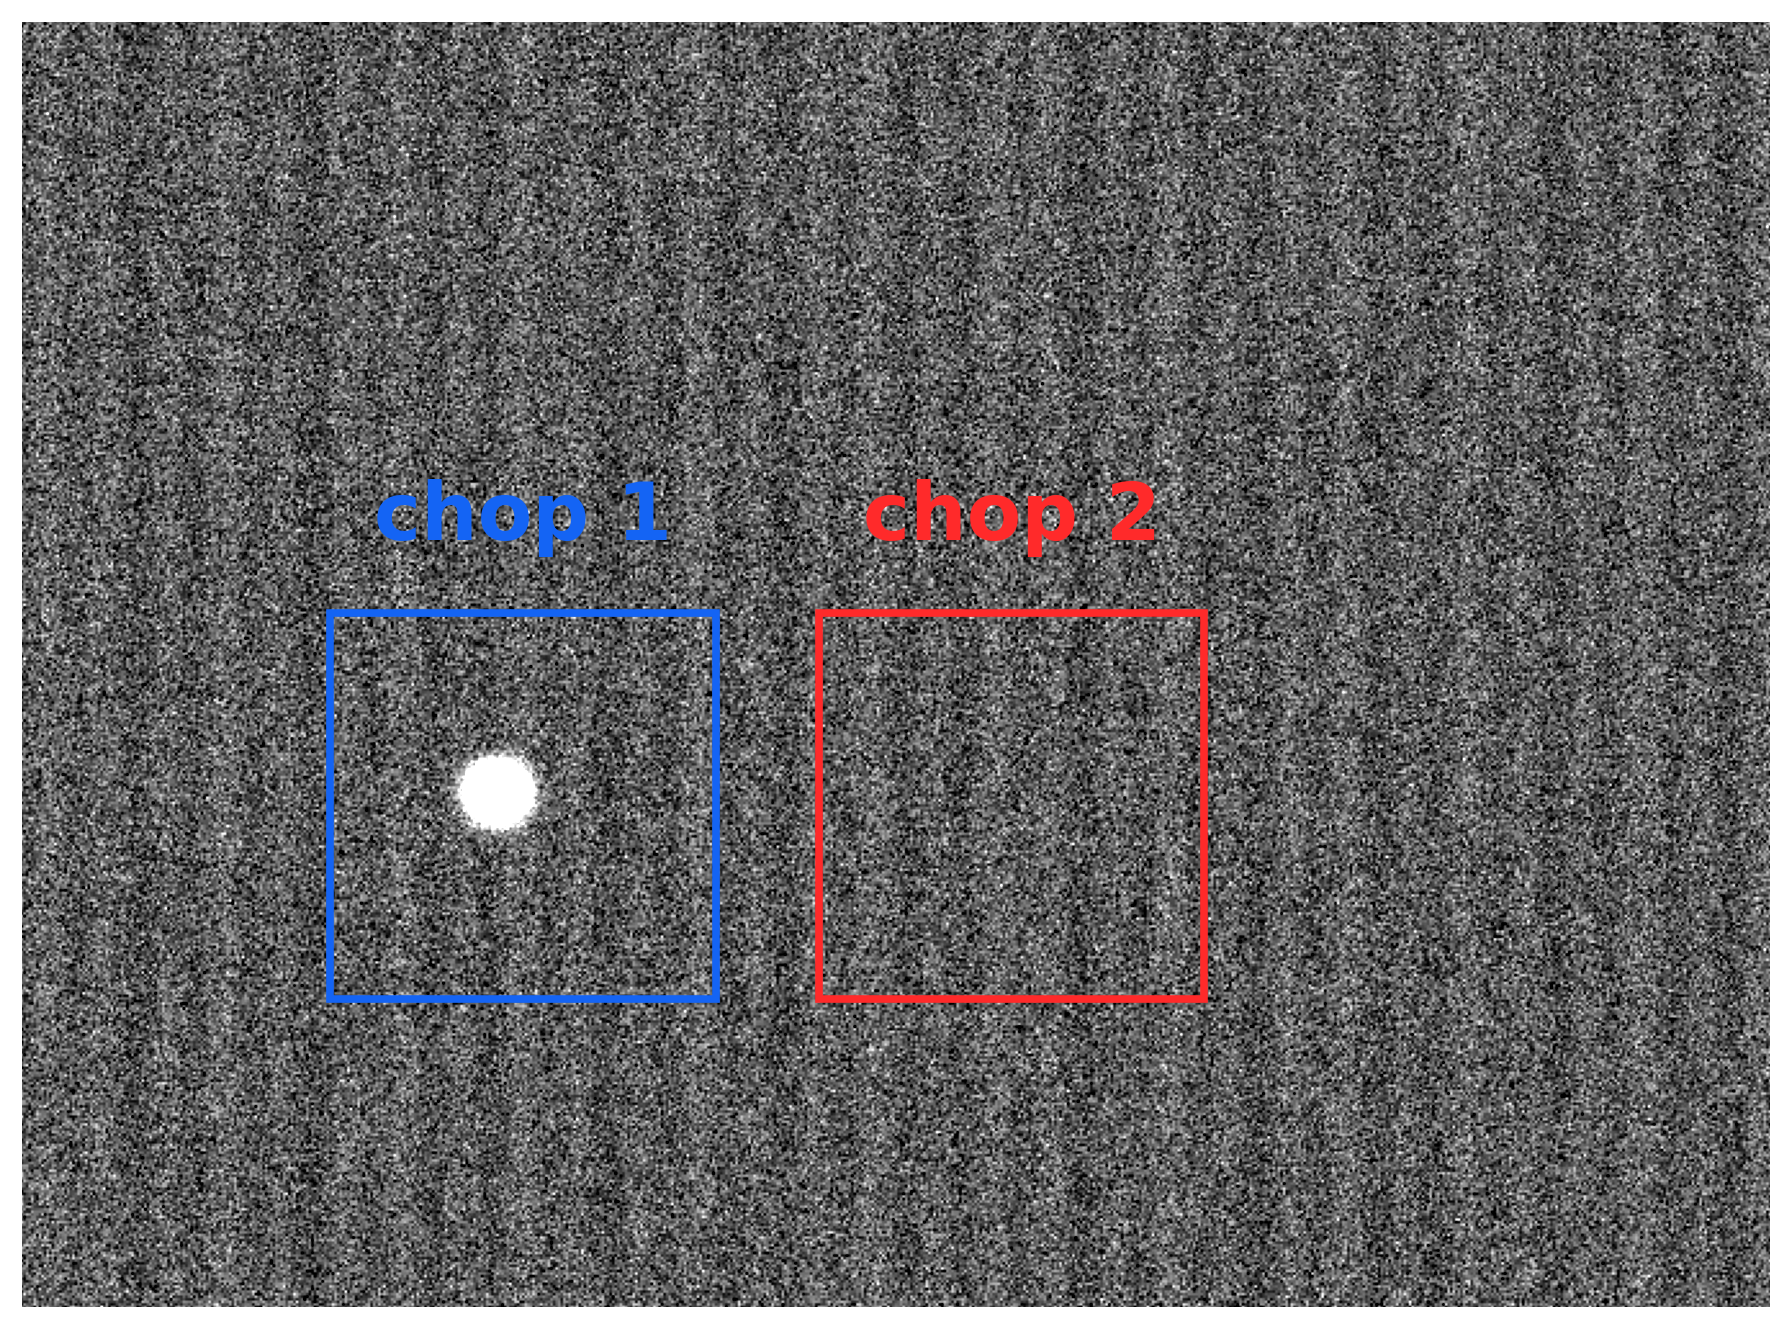

In [ ]:
# Figure Generation for 699 project 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

rng = np.random.default_rng(42)

# Image size
ny, nx = 1024, 1024
y, x = np.mgrid[0:ny, 0:nx]

# Background: Gaussian noise + a mild detector-like column pattern
background = rng.normal(loc=0.0, scale=1.0, size=(ny, nx))
column_pattern = 0.20 * np.sin(2 * np.pi * x / 23.0) + 0.08 * np.sin(2 * np.pi * x / 61.0)
image = background + column_pattern

def gaussian_2d(x, y, x0, y0, sigma, amp):
    return amp * np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma**2))

# Rectangle geometry
rect_w = 100
rect_h = 100

# Chop positions
chop1_xy = (300, 380)   # lower-left corner of chop 1 rectangle
gap = 40
chop2_xy = (chop1_xy[0] + rect_w + gap, chop1_xy[1])

# Put one point source in each chop position
src1 = (chop1_xy[0] + rect_w // 2 - 10, chop1_xy[1] + rect_h // 2 + 5)
#src2 = (chop2_xy[0] + rect_w // 2 + 5, chop2_xy[1] + rect_h // 2 + 5)

# Add simulated point sources
image += gaussian_2d(x, y, src1[0], src1[1], sigma=6.0, amp=50.0)
#image += gaussian_2d(x, y, src2[0], src2[1], sigma=6.0, amp=70.0)

# Display limits
vmin = np.percentile(image, 5)
vmax = np.percentile(image, 99.8)

fig, ax = plt.subplots(figsize=(8, 8), dpi=220)
ax.imshow(image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

blue = "#1464F4"
red = "#FF2A2A"

ax.add_patch(Rectangle(chop1_xy, rect_w, rect_h, fill=False, ec=blue, lw=2.5))
ax.add_patch(Rectangle(chop2_xy, rect_w, rect_h, fill=False, ec=red, lw=2.5))

ax.text(
    chop1_xy[0] + rect_w / 2,
    chop1_xy[1] + rect_h + 22,
    "chop 1",
    color=blue,
    fontsize=26,
    fontweight="bold",
    ha="center",
    va="bottom",
)
ax.text(
    chop2_xy[0] + rect_w / 2,
    chop2_xy[1] + rect_h + 22,
    "chop 2",
    color=red,
    fontsize=26,
    fontweight="bold",
    ha="center",
    va="bottom",
)

# Optional crop for publication-style framing
ax.set_xlim(180, 860)
ax.set_ylim(260, 760)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=0.2)
#plt.savefig("chop_demo_python.png", bbox_inches="tight", pad_inches=0.02)
#plt.savefig("chop_demo_python.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()